## Self Attention (Scaled Dot Product attention)

1. We want to compute context vectors as weighted sums over the input vectors specific to a certain input element.
2. We will introduce weight matrices that are updated during model training.
3. These trainable weight matrices are crucial so that the model can learn to produce "good" context vectors.
4. Three matrices needed for training - 
   1. Query Matrix (W<sub>q</sub>)
   2. Key Matrix (W<sub>k</sub>)
   3. Value Matrix (W<sub>v</sub>)

In [5]:
import torch

inputs = torch.tensor(
    [[0.43, 0.15, 0.89],  # Your      (x^1)
     [0.55, 0.87, 0.66],  # journey   (x^2)
     [0.57, 0.85, 0.64],  # starts    (x^3)
     [0.22, 0.58, 0.33],  # with      (x^4)
     [0.77, 0.25, 0.10],  # one       (x^5)
     [0.05, 0.80, 0.55]]  # step      (x^6)
)

In [6]:
d_in = inputs.shape[1]
d_out = 2 ## lets chose this

In [7]:

torch.manual_seed(123)

## nn.Parameter is an extended tensor 
W_query = torch.nn.Parameter(torch.rand(d_in,d_out), requires_grad = False)
W_key = torch.nn.Parameter(torch.rand(d_in,d_out), requires_grad = False)
W_value = torch.nn.Parameter(torch.rand(d_in,d_out), requires_grad = False)

In [8]:
print(W_query)
print(W_key)

Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])
Parameter containing:
tensor([[0.1366, 0.1025],
        [0.1841, 0.7264],
        [0.3153, 0.6871]])


#### Single input token

In [9]:
x_1 = inputs[1]
query_1 = x_1 @ W_query
key_1 = x_1 @ W_key
value_1 = x_1 @ W_value
print(query_1,key_1,value_1)

tensor([0.4306, 1.4551]) tensor([0.4433, 1.1419]) tensor([0.3951, 1.0037])


### all input tokens

In [10]:
keys = inputs @ W_key
values = inputs @ W_value
queries = inputs @ W_query

print(keys.shape)
print(values.shape)
print(queries.shape)

torch.Size([6, 2])
torch.Size([6, 2])
torch.Size([6, 2])


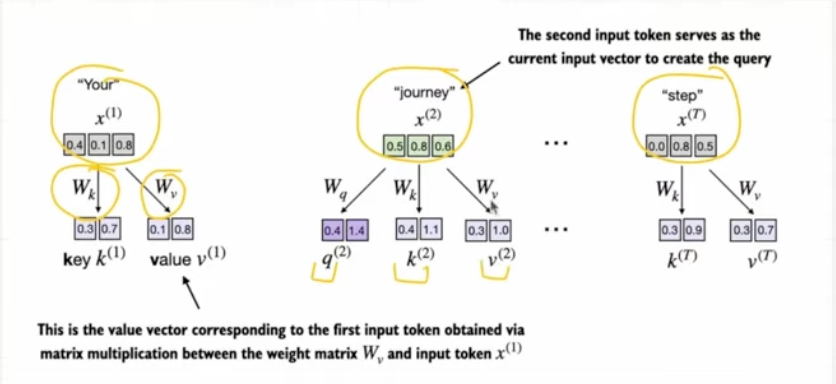

#### computing attention scores

Suppose consider second token, We need to get that token attend to other tokens

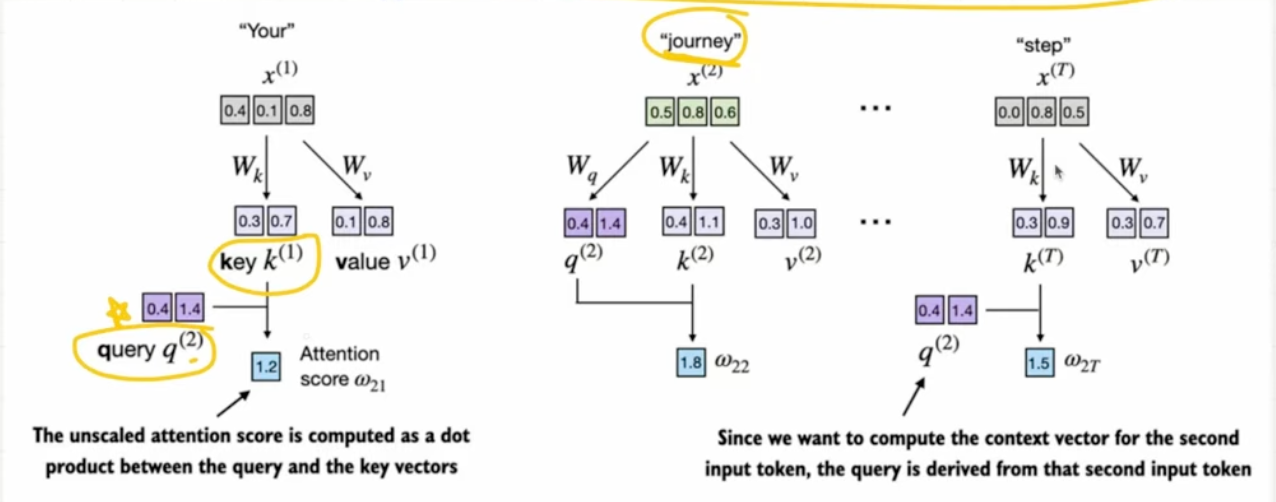

### computing attention scores matrix

In [11]:
attention_scores = queries @ keys.T
print(attention_scores)

tensor([[0.9231, 1.3545, 1.3241, 0.7910, 0.4032, 1.1330],
        [1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440],
        [1.2544, 1.8284, 1.7877, 1.0654, 0.5508, 1.5238],
        [0.6973, 1.0167, 0.9941, 0.5925, 0.3061, 0.8475],
        [0.6114, 0.8819, 0.8626, 0.5121, 0.2707, 0.7307],
        [0.8995, 1.3165, 1.2871, 0.7682, 0.3937, 1.0996]])


#### Scaling the attention scores

In [12]:
import math
attention_scores= attention_scores/math.sqrt(d_out)
print(attention_scores)

tensor([[0.6528, 0.9578, 0.9363, 0.5593, 0.2851, 0.8011],
        [0.8984, 1.3098, 1.2806, 0.7633, 0.3944, 1.0918],
        [0.8870, 1.2929, 1.2641, 0.7534, 0.3895, 1.0775],
        [0.4930, 0.7189, 0.7029, 0.4190, 0.2164, 0.5993],
        [0.4323, 0.6236, 0.6099, 0.3621, 0.1914, 0.5167],
        [0.6361, 0.9309, 0.9101, 0.5432, 0.2784, 0.7776]])


#### Why divided by Sqrt of dimension of keys (d<sub>k</sub>)

Stability in learning

1. The softmax function is sensitive to the magnitude of its inputs. When the inputs are large, the differences between the exponential values of each input becomes much more pronounced. 

2. This causes the softmax output to become "peaky", where the highest value recives almost all the probability mass, and the rest recieves very little.

3. In attention mechanisms, particularly in transformer, if the dot products between query and key vectors become too large, the attention scores can become very large. This results in a very sharp softmax distribution and results in the model overly confident in one particular "key". Such sharp distributions can make learning unstable

In [13]:
### Example code showing above

tensor = torch.tensor([0.1,-0.2,0.3,-0.2,0.5])
softmax_result = torch.softmax(tensor,dim=-1)
print("Softmax without scaling:", softmax_result)

scaled_tensor = tensor * 8
scaled_softmax_result = torch.softmax(scaled_tensor,dim=-1)
print("Softmax after scaling:", scaled_softmax_result)

Softmax without scaling: tensor([0.1925, 0.1426, 0.2351, 0.1426, 0.2872])
Softmax after scaling: tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])


To make the variance of the dot product stable

1. The dot product of Q and K increases the variance because of multiplying two random numbers increases the variance.
2. The increase in variance grows with the dimension.
3. Dividing by sqrt (dimension) keeps the variance close to 1

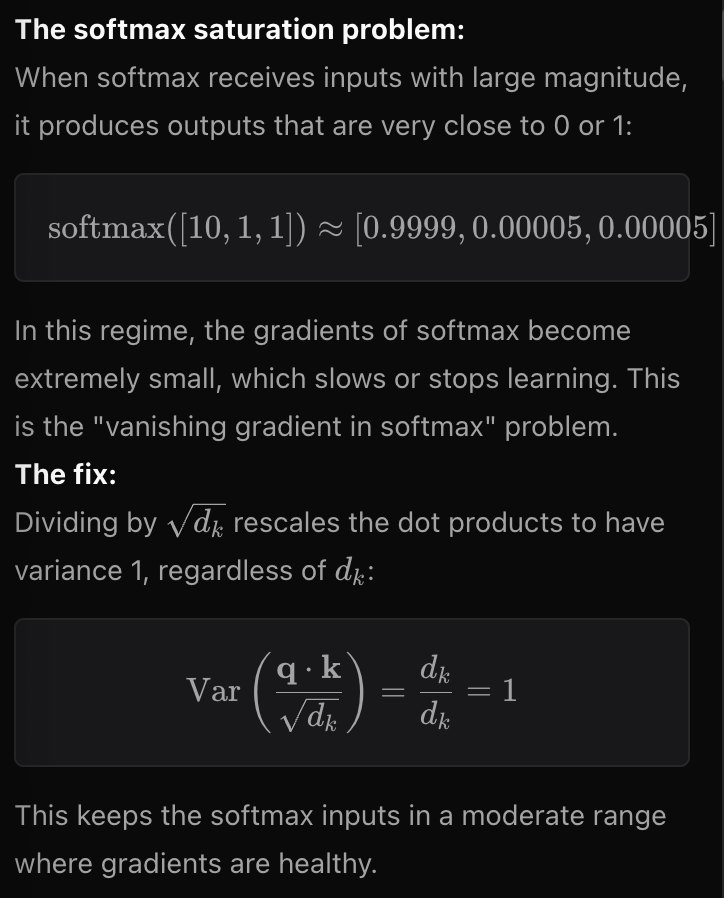

In [14]:
import numpy as np

def compute_variance(dim,num_trails=1000):
    dot_products = []
    scaled_dot_products = []
    
    for _ in range(num_trails):
        ## Sample from normal distribution
        q = np.random.randn(dim)
        k = np.random.randn(dim)
        
        dot_product = np.dot(q,k)
        dot_products.append(dot_product)
        
        scaled_dot_product = dot_product/np.sqrt(dim)
        scaled_dot_products.append(scaled_dot_product)
        
    variance_before_scaling = np.var(dot_products)
    variance_after_scaling = np.var(scaled_dot_products)
       
    print(variance_before_scaling, variance_after_scaling)
    
compute_variance(1000) 
compute_variance(20) 
        

974.9635318344054 0.9749635318344055
20.045832760227896 1.0022916380113944


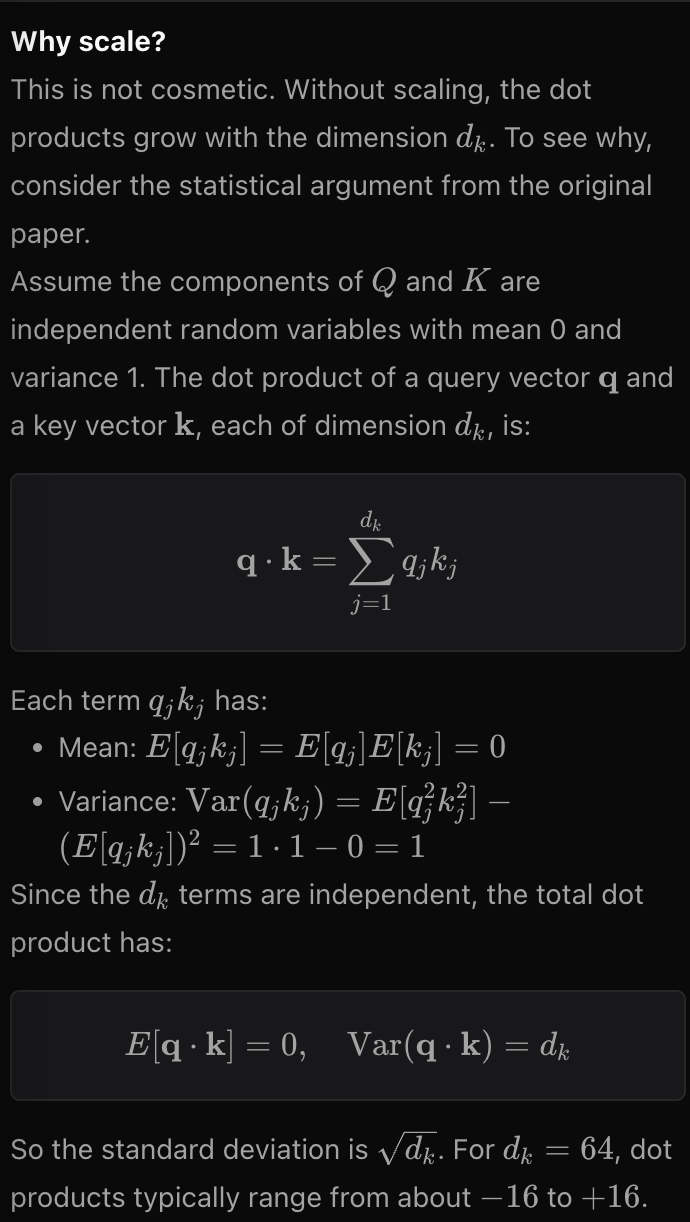

#### Applying softmax and Getting attention weights

In [15]:
attention_weights = torch.softmax(attention_scores, dim = -1)

#### Final context vector building

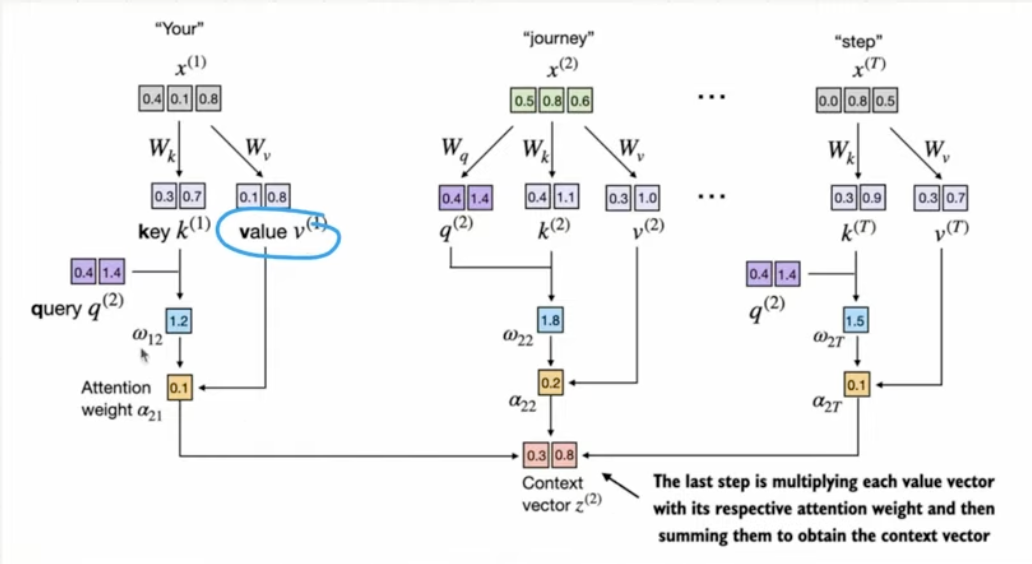

In [16]:
context_vectors = attention_weights @ values

## complete self attention pipeline

In [17]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):
    
    def __init__(self,d_in,d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in,d_out))
        self.W_key = nn.Parameter(torch.rand(d_in,d_out))
        self.W_value = nn.Parameter(torch.rand(d_in,d_out))
        
        
    def forward(self,x):
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value
        
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores/keys.shape[-1]**0.5, dim =-1)
        
        context_vec = attn_weights @ values
        return context_vec

In [18]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in,d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


## Improvements

1. We can improve SelfAttention_v1 implementation further by utilizing PyTorch's nn.Linear layers, which effectively perform matrix multiplication when the bias units are disabled

2. Additionally, a significant advantage of using nn.Linear instead of manually implementing nn.Parameter(torch.randn(...)) is that nn.Linear has a optimized weight intilalization scheme, contributing to more stable and effective model training.

In [19]:
import torch.nn as nn

class SelfAttention_v2(nn.Module):
    
    def __init__(self,d_in,d_out,qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in,d_out,bias = qkv_bias)
        self.W_key = nn.Linear(d_in,d_out,bias = qkv_bias)
        self.W_value = nn.Linear(d_in,d_out,bias = qkv_bias)
        
        
    def forward(self,x):
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value
        
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores/keys.shape[-1]**0.5, dim =-1)
        
        context_vec = attn_weights @ values
        return context_vec

In [20]:
torch.manual_seed(123)
sa_v2 = SelfAttention_v2(d_in,d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


### Why Key, Query, Value

1. Query :- Analogos to search query in a database: it represents thye current token the model focuses on

2. Key :- In attention mechansim, each item in input sequence has a key. keys are used to match with the query

3. Value :- It represnets the actual content or representation of the inout items. Once the model determines which keys (which parts of input) are most relevant to the query(current focus item), it retrieves corresponding values